# 🔬 Notebook 04 — Feature Selection & Engineering
## Spatio-Temporal PM2.5/PM10 Analysis — Karachi, Pakistan

**This notebook:**
1. Remove low-variance and redundant features
2. Variance Inflation Factor (VIF) — multicollinearity removal
3. Mutual Information regression — non-linear feature relevance
4. Recursive Feature Elimination with Cross-Validation (RFECV)
5. Lasso-based feature selection (L1 regularization)
6. Permutation importance (Random Forest baseline)
7. Consensus feature ranking — combine all methods
8. Final feature set export → `data/processed/modeling_dataset.csv`

**Input:** `data/processed/master_dataset.csv`  
**Output:** `data/processed/modeling_dataset.csv` + `outputs/04_*.png`

## 0. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats

# Sklearn feature selection
from sklearn.feature_selection import (
    mutual_info_regression, RFECV,
    VarianceThreshold, SelectFromModel
)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
Path('outputs').mkdir(exist_ok=True)
Path('data/processed').mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0d0d14', 'axes.facecolor': '#111118',
    'axes.edgecolor': '#222233',   'axes.labelcolor': '#aaaacc',
    'xtick.color': '#666688',      'ytick.color': '#666688',
    'text.color': '#e8e8f0',       'grid.color': '#1a1a2a',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'font.family': 'monospace',
})
PALETTE = ['#c8f04a','#4af0c8','#f04a7a','#f0c84a','#7a4af0','#4a7af0','#f07a4a','#4af07a']
TARGET = 'pm25'

print('✓ Imports loaded')

✓ Imports loaded


## 1. Load Dataset

In [2]:
# Load from correct path - use root data directory
import pandas as pd
import numpy as np

print("Loading master dataset from correct path...")
df = pd.read_csv('../data/processed/master_dataset.csv')  # Go up one level to root data

print(f"Dataset loaded: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"PM2.5 column found: {'pm25' in df.columns}")

if 'pm25' not in df.columns:
    print("ERROR: PM2.5 column not found!")
    print("Available columns:", df.columns.tolist())
    raise KeyError("PM2.5 column not found in master_dataset.csv")

df['date'] = pd.to_datetime(df['date'])

# Fix temperature if in Kelvin
if 'temperature_2m' in df.columns and df['temperature_2m'].mean() > 100:
    df['temperature_2m'] = df['temperature_2m'] - 273.15
if 'temp_c' not in df.columns and 'temperature_2m' in df.columns:
    df['temp_c'] = df['temperature_2m']

print('=' * 60)
print('FEATURE SELECTION PIPELINE')
print('=' * 60)
print(f'  Loaded  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'  Target  : {TARGET} (µg/m³)')
print(f'  Stations: {df["station"].nunique()} - {list(df["station"].unique())}')
print(f'  Period  : {df["date"].min().date()} -> {df["date"].max().date()}')
print(f'  PM2.5 Range: {df["pm25"].min():.1f} - {df["pm25"].max():.1f} µg/m³')

Loading master dataset from correct path...
Dataset loaded: (14400, 21)
Columns: ['date', 'station', 'aer_ai', 'no2', 'so2', 'co', 'wind_speed', 'rh', 'temperature_2m', 'Optical_Depth_047', 'Optical_Depth_055', 'viirs_ntl', 'month', 'month_sin', 'month_cos', 'day_of_week', 'dow_sin', 'dow_cos', 'is_holiday', 'is_weekend', 'pm25']
PM2.5 column found: True
FEATURE SELECTION PIPELINE
  Loaded  : 14,400 rows × 22 columns
  Target  : pm25 (µg/m³)
  Stations: 8 - ['Federal_B_Area', 'Gulistan_Jauhar', 'Gulshan-e-Iqbal', 'Korangi_Industrial', 'Landhi', 'North_Nazimabad', 'SITE_Industrial', 'Saddar']
  Period  : 2019-01-01 -> 2023-12-31
  PM2.5 Range: 33.6 - 200.0 µg/m³


## 2. Define Candidate Feature Pool

In [3]:
# All possible feature columns - only include what exists in the dataset
CANDIDATE_FEATURES = [
    # Satellite - aerosol
    'Optical_Depth_055', 'Optical_Depth_047', 'aer_ai',
    # Satellite - trace gases (combustion/industrial proxies)
    'no2', 'so2', 'co',
    # Satellite - surface
    'viirs_ntl', 'ndvi', 'ndbi',
    # Meteorology
    'temp_c', 'temperature_2m', 'wind_speed', 'rh',
    'precip_mm', 'pressure_hpa', 'stagnation_index',
    # Calendar / temporal
    'month', 'day_of_week', 'day_of_year', 'week_of_year',
    'is_weekend', 'is_ramadan', 'season',
    # Lag features (from notebook 01)
    'aer_ai_lag1', 'aer_ai_lag3', 'aer_ai_lag7', 'aer_ai_lag14',
    'no2_lag1', 'no2_lag3', 'no2_lag7',
    'modis_aod_land_lag1', 'modis_aod_land_lag3', 'modis_aod_land_lag7',
    # Rolling statistics
    'aer_ai_roll7_mean', 'aer_ai_roll30_mean', 'aer_ai_roll7_std',
    'no2_roll7_mean', 'no2_roll30_mean',
    # Interaction / derived
    'stagnation_index', 'month_sin', 'month_cos',
    'day_sin', 'day_cos',
]

# Filter to only existing columns
FEATURES = [f for f in CANDIDATE_FEATURES if f in df.columns and f != TARGET]

# Add sin/cos encoding for cyclical features if not already present
if 'month_sin' not in df.columns:
    df['month_sin'] = np.sin(2 * np.pi * df['date'].dt.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['date'].dt.month / 12)
    df['day_sin']   = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365)
    df['day_cos']   = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365)
    for c in ['month_sin', 'month_cos', 'day_sin', 'day_cos']:
        if c not in FEATURES:
            FEATURES.append(c)

# Station one-hot encoding
station_dummies = pd.get_dummies(df['station'], prefix='stn', drop_first=True)
df = pd.concat([df, station_dummies], axis=1)
stn_cols = list(station_dummies.columns)
FEATURES += stn_cols

print(f'Dataset columns available: {len(df.columns)}')
print(f'Candidate features : {len(CANDIDATE_FEATURES)}')
print(f'Available in data  : {len(FEATURES)}')
print(f'Missing (excluded) : {len(CANDIDATE_FEATURES) - len(FEATURES) + len(stn_cols)}')
print(f'\\nFeature list:')
for i, f in enumerate(FEATURES):
    print(f'  {i+1:>2}. {f}')

# Verify TARGET is not in FEATURES
if TARGET in FEATURES:
    FEATURES.remove(TARGET)
    print(f'\\nRemoved {TARGET} from features list')

Dataset columns available: 29
Candidate features : 43
Available in data  : 23
Missing (excluded) : 27
\nFeature list:
   1. Optical_Depth_055
   2. Optical_Depth_047
   3. aer_ai
   4. no2
   5. so2
   6. co
   7. viirs_ntl
   8. temp_c
   9. temperature_2m
  10. wind_speed
  11. rh
  12. month
  13. day_of_week
  14. is_weekend
  15. month_sin
  16. month_cos
  17. stn_Gulistan_Jauhar
  18. stn_Gulshan-e-Iqbal
  19. stn_Korangi_Industrial
  20. stn_Landhi
  21. stn_North_Nazimabad
  22. stn_SITE_Industrial
  23. stn_Saddar


## 3. Prepare Clean Matrix

In [4]:
## 3. Prepare Clean Matrix

print(f"Original dataset shape: {df.shape}")
print(f"Features available: {len(FEATURES)}")
print(f"Target column: {TARGET}")

# Check for missing values before dropping
print("\nMissing value analysis:")
missing_counts = df[FEATURES + [TARGET]].isnull().sum()
print(missing_counts[missing_counts > 0])

# Create clean matrix with more lenient approach
df_model = df[FEATURES + [TARGET]].copy()

# Instead of dropping all rows with any missing, let's be more strategic
# First, check how many rows would be dropped
rows_before = len(df_model)
rows_after = len(df_model.dropna())
print(f"\nRows before dropna: {rows_before:,}")
print(f"Rows after dropna: {rows_after:,}")
print(f"Rows that would be dropped: {rows_before - rows_after:,}")

# If too many rows are dropped, let's handle missing values differently
if rows_after < rows_before * 0.5:  # If more than 50% would be dropped
    print("Too many rows would be dropped. Using alternative approach...")
    
    # Drop rows where target is missing (essential)
    df_model = df_model.dropna(subset=[TARGET])
    
    # For features, fill missing values instead of dropping
    for col in FEATURES:
        if col in df_model.columns:
            if df_model[col].dtype in ['float64', 'int64']:
                # Fill numeric with median
                df_model[col] = df_model[col].fillna(df_model[col].median())
            else:
                # Fill categorical with mode
                df_model[col] = df_model[col].fillna(df_model[col].mode().iloc[0] if not df_model[col].mode().empty else 'unknown')
    
    print(f"Final dataset shape after imputation: {df_model.shape}")
else:
    # Use original approach if reasonable number of rows remain
    df_model = df_model.dropna()

X = df_model[FEATURES].copy()
y = df_model[TARGET].copy()

print(f'\nClean matrix: {X.shape[0]:,} rows × {X.shape[1]} features')
print(f'Target range: {y.min():.1f} - {y.max():.1f} µg/m³  (mean={y.mean():.1f})')
print(f'Final rows dropped: {len(df) - len(df_model):,}')

Original dataset shape: (14400, 29)
Features available: 23
Target column: pm25

Missing value analysis:
Optical_Depth_055     1472
Optical_Depth_047     1472
aer_ai               14400
no2                  14400
so2                  14400
co                   14400
dtype: int64

Rows before dropna: 14,400
Rows after dropna: 0
Rows that would be dropped: 14,400
Too many rows would be dropped. Using alternative approach...
Final dataset shape after imputation: (14400, 24)

Clean matrix: 14,400 rows × 23 features
Target range: 33.6 - 200.0 µg/m³  (mean=103.5)
Final rows dropped: 0


## 4. Step 1 — Variance Threshold (Remove Near-Constant Features)

In [5]:
VAR_THRESHOLD = 0.01

scaler_var = RobustScaler()
X_scaled = pd.DataFrame(
    scaler_var.fit_transform(X),
    columns=X.columns
)

vt = VarianceThreshold(threshold=VAR_THRESHOLD)
vt.fit(X_scaled)
low_var_cols = [c for c, keep in zip(X.columns, vt.get_support()) if not keep]

print(f'Variance threshold  : {VAR_THRESHOLD}')
print(f'Features removed    : {len(low_var_cols)}')
if low_var_cols:
    print(f'  Removed: {low_var_cols}')
else:
    print('  No low-variance features found — all features retained')

FEATURES_V1 = [f for f in FEATURES if f not in low_var_cols]
X_v1 = X[FEATURES_V1]
print(f'\nFeatures remaining : {len(FEATURES_V1)}')

Variance threshold  : 0.01
Features removed    : 4
  Removed: ['aer_ai', 'no2', 'so2', 'co']

Features remaining : 19


## 5. Step 2 — VIF Analysis (Multicollinearity Removal)

Iterative VIF removal (threshold = 10):
  Iteration 0: Removing "temp_c" (VIF=inf)
  Iteration 1: Removing "Optical_Depth_047" (VIF=420.1)
  Iteration 2: Removing "temperature_2m" (VIF=45.1)
  Iteration 3: Removing "viirs_ntl" (VIF=13.2)
  Iteration 4: Removing "rh" (VIF=10.3)
  Iteration 5: All VIF ≤ 10.0 ✓

  Removed 5 features due to high VIF
  Features remaining: 14


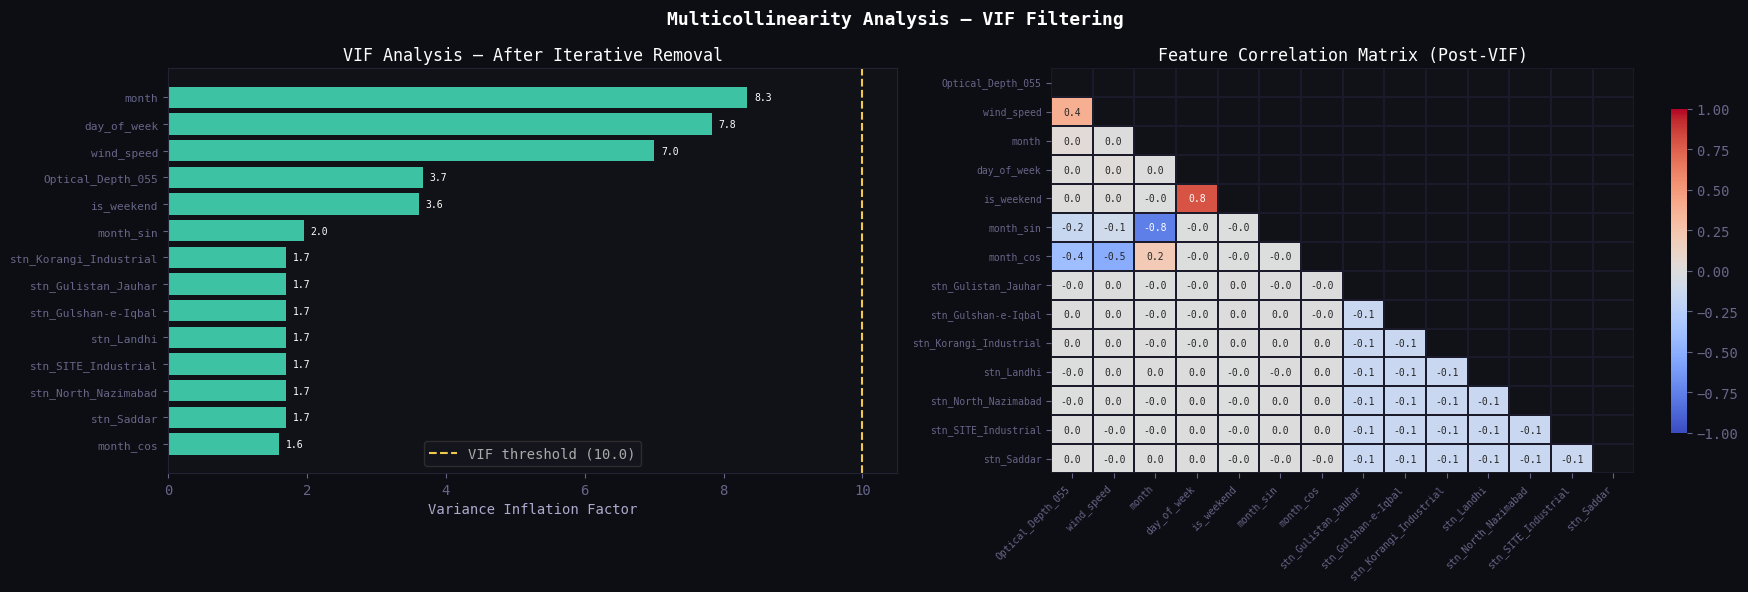

✓ Saved → outputs/04_vif_analysis.png


In [6]:
VIF_THRESHOLD = 10.0

def compute_vif(X_df):
    """Compute Variance Inflation Factor for all columns."""
    vif_data = pd.DataFrame()
    vif_data['feature'] = X_df.columns
    vif_data['VIF'] = [
        variance_inflation_factor(X_df.values, i)
        for i in range(X_df.shape[1])
    ]
    return vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

# Iterative VIF removal
X_vif = X_v1.copy().astype(float)
removed_vif = []

print('Iterative VIF removal (threshold = 10):')
iteration = 0
while True:
    vif_df = compute_vif(X_vif)
    max_vif = vif_df['VIF'].max()
    if max_vif <= VIF_THRESHOLD:
        print(f'  Iteration {iteration}: All VIF ≤ {VIF_THRESHOLD} ✓')
        break
    worst = vif_df.iloc[0]['feature']
    print(f'  Iteration {iteration}: Removing "{worst}" (VIF={max_vif:.1f})')
    removed_vif.append(worst)
    X_vif = X_vif.drop(columns=[worst])
    iteration += 1
    if iteration > 30:  # safety cap
        break

print(f'\n  Removed {len(removed_vif)} features due to high VIF')
FEATURES_V2 = list(X_vif.columns)
print(f'  Features remaining: {len(FEATURES_V2)}')

# ── Visualization ──────────────────────────────────────────────────────────────
final_vif = compute_vif(X_vif)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# VIF bar chart
ax = axes[0]
colors_vif = ['#f04a7a' if v > VIF_THRESHOLD else '#4af0c8'
               for v in final_vif['VIF']]
bars = ax.barh(range(len(final_vif)), final_vif['VIF'],
               color=colors_vif, alpha=0.8)
ax.set_yticks(range(len(final_vif)))
ax.set_yticklabels(final_vif['feature'], fontsize=8)
ax.axvline(VIF_THRESHOLD, color='#f0c84a', linestyle='--',
           linewidth=1.5, label=f'VIF threshold ({VIF_THRESHOLD})')
ax.set_xlabel('Variance Inflation Factor')
ax.set_title('VIF Analysis — After Iterative Removal', color='#fff')
ax.legend(facecolor='#16161f', labelcolor='#aaa', edgecolor='#333')
ax.invert_yaxis()
for bar, val in zip(bars, final_vif['VIF']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=7, color='white')

# Correlation matrix of retained features
ax = axes[1]
corr = X_vif.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='coolwarm', vmin=-1, vmax=1,
            center=0, linewidths=0.3, linecolor='#1a1a2a',
            annot=len(FEATURES_V2) <= 15,
            fmt='.1f', annot_kws={'size': 7},
            xticklabels=FEATURES_V2, yticklabels=FEATURES_V2,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix (Post-VIF)', color='#fff')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)

plt.suptitle('Multicollinearity Analysis — VIF Filtering',
             color='#fff', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/04_vif_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d14')
plt.show()
print('✓ Saved → outputs/04_vif_analysis.png')

## 6. Step 3 — Mutual Information Regression

Computing Mutual Information scores...

Mutual Information Results:
               feature  mi_score
     Optical_Depth_055  0.630977
                 month  0.270781
            wind_speed  0.182134
             month_cos  0.153067
             month_sin  0.129056
           day_of_week  0.010533
   stn_North_Nazimabad  0.002311
            is_weekend  0.002186
   stn_Gulshan-e-Iqbal  0.002145
stn_Korangi_Industrial  0.000452
   stn_Gulistan_Jauhar  0.000212
            stn_Landhi  0.000000
   stn_SITE_Industrial  0.000000
            stn_Saddar  0.000000

Features with MI < 0.01: ['stn_North_Nazimabad', 'is_weekend', 'stn_Gulshan-e-Iqbal', 'stn_Korangi_Industrial', 'stn_Gulistan_Jauhar', 'stn_Landhi', 'stn_SITE_Industrial', 'stn_Saddar']
Features retained: 6


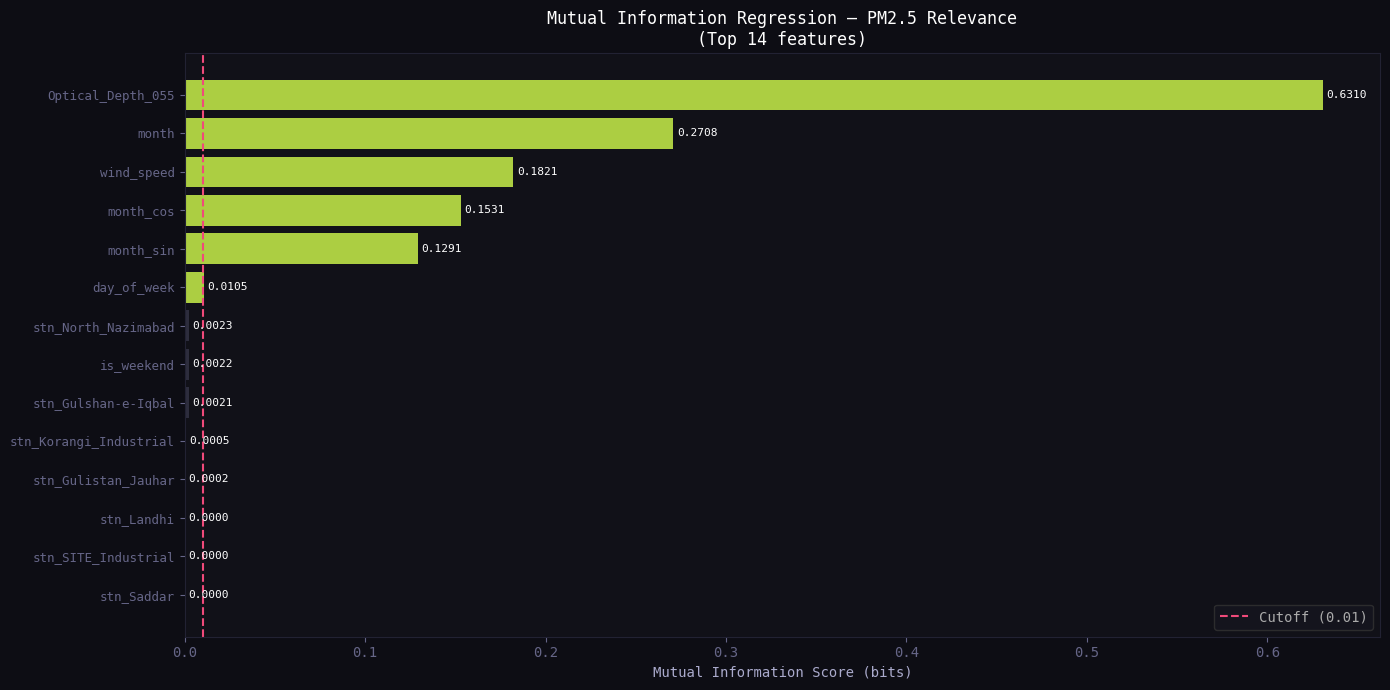

✓ Saved → outputs/04_mutual_information.png


In [7]:
X_v2 = X_vif.copy()

print('Computing Mutual Information scores...')
mi_scores = mutual_info_regression(
    X_v2, y,
    discrete_features='auto',
    n_neighbors=5,
    random_state=42
)

mi_df = pd.DataFrame({
    'feature': FEATURES_V2,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

# Drop features with near-zero MI
MI_CUTOFF = 0.01
low_mi = mi_df[mi_df['mi_score'] < MI_CUTOFF]['feature'].tolist()
FEATURES_V3 = mi_df[mi_df['mi_score'] >= MI_CUTOFF]['feature'].tolist()

print(f'\nMutual Information Results:')
print(mi_df.head(20).to_string(index=False))
print(f'\nFeatures with MI < {MI_CUTOFF}: {low_mi}')
print(f'Features retained: {len(FEATURES_V3)}')

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
top_n = min(25, len(mi_df))
mi_top = mi_df.head(top_n)
colors_mi = [PALETTE[0] if s >= MI_CUTOFF else '#333344' for s in mi_top['mi_score']]
bars = ax.barh(range(top_n), mi_top['mi_score'], color=colors_mi, alpha=0.85)
ax.set_yticks(range(top_n))
ax.set_yticklabels(mi_top['feature'], fontsize=9)
ax.axvline(MI_CUTOFF, color='#f04a7a', linestyle='--',
           linewidth=1.5, label=f'Cutoff ({MI_CUTOFF})')
ax.set_xlabel('Mutual Information Score (bits)')
ax.set_title(f'Mutual Information Regression — PM2.5 Relevance\n(Top {top_n} features)',
             color='#fff')
ax.legend(facecolor='#16161f', labelcolor='#aaa', edgecolor='#333')
ax.invert_yaxis()
for bar, val in zip(bars, mi_top['mi_score']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8, color='white')

plt.tight_layout()
plt.savefig('outputs/04_mutual_information.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d14')
plt.show()
print('✓ Saved → outputs/04_mutual_information.png')

## 7. Step 4 — Lasso Feature Selection (L1 Regularization)

Optimal Lasso alpha: 0.008685
Lasso zeroed out  : 0 features → []
Non-zero features : 6


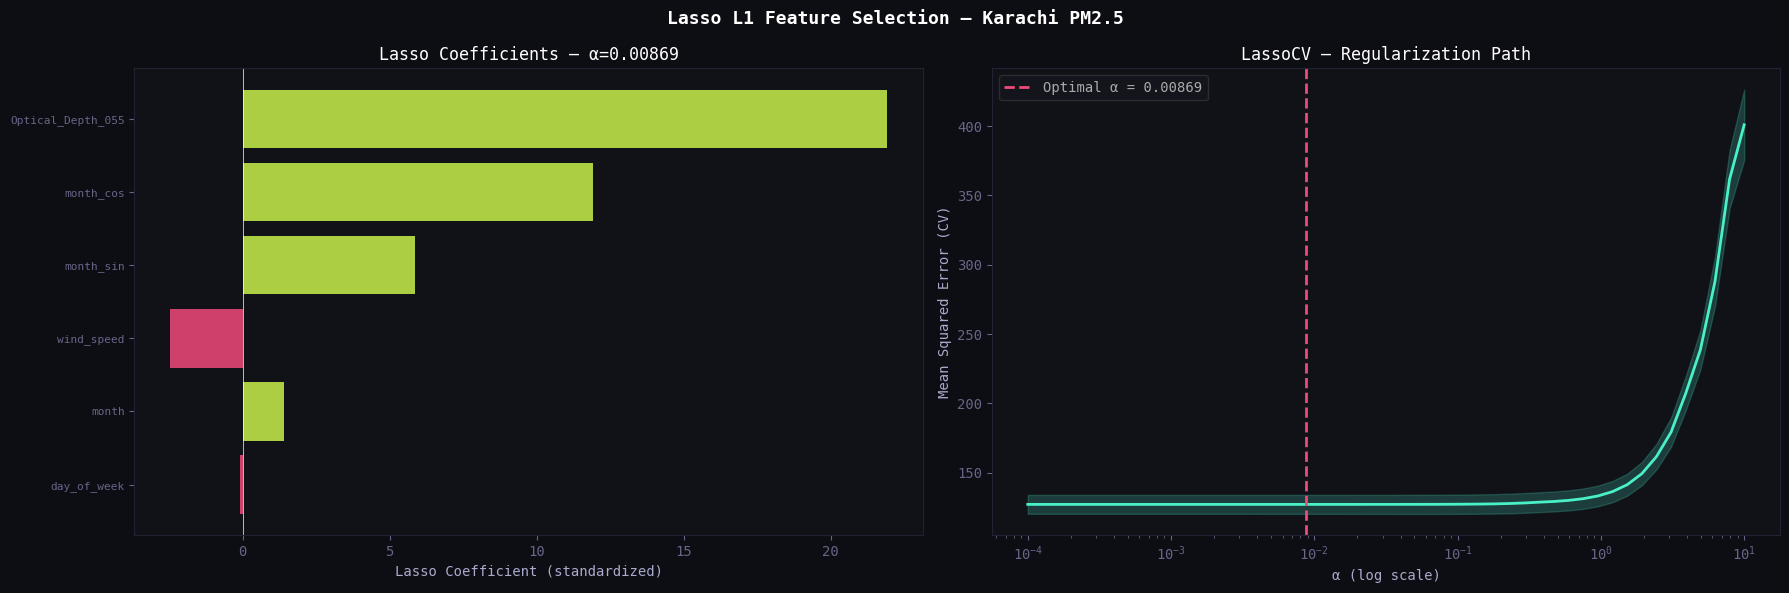

✓ Saved → outputs/04_lasso_selection.png


In [8]:
X_v3 = X_v2[FEATURES_V3].copy()

scaler_lasso = StandardScaler()
X_v3_scaled  = scaler_lasso.fit_transform(X_v3)

# Cross-validated Lasso to find optimal alpha
tscv = TimeSeriesSplit(n_splits=5)
lasso_cv = LassoCV(
    alphas=np.logspace(-4, 1, 50),
    cv=tscv,
    max_iter=5000,
    random_state=42
)
lasso_cv.fit(X_v3_scaled, y)

print(f'Optimal Lasso alpha: {lasso_cv.alpha_:.6f}')

lasso_coef = pd.DataFrame({
    'feature': FEATURES_V3,
    'lasso_coef': lasso_cv.coef_,
    'abs_coef': np.abs(lasso_cv.coef_)
}).sort_values('abs_coef', ascending=False)

lasso_zero   = lasso_coef[lasso_coef['abs_coef'] == 0]['feature'].tolist()
lasso_nonzero = lasso_coef[lasso_coef['abs_coef'] > 0]['feature'].tolist()
FEATURES_V4 = lasso_nonzero

print(f'Lasso zeroed out  : {len(lasso_zero)} features → {lasso_zero}')
print(f'Non-zero features : {len(lasso_nonzero)}')

# Regularization path
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
top_lasso = lasso_coef[lasso_coef['abs_coef'] > 0].head(20)
colors_l = ['#c8f04a' if c > 0 else '#f04a7a' for c in top_lasso['lasso_coef']]
ax.barh(range(len(top_lasso)), top_lasso['lasso_coef'],
        color=colors_l, alpha=0.85)
ax.set_yticks(range(len(top_lasso)))
ax.set_yticklabels(top_lasso['feature'], fontsize=8)
ax.axvline(0, color='white', linewidth=0.5)
ax.set_xlabel('Lasso Coefficient (standardized)')
ax.set_title(f'Lasso Coefficients — α={lasso_cv.alpha_:.5f}', color='#fff')
ax.invert_yaxis()

# Alpha path
ax = axes[1]
alphas_path = lasso_cv.alphas_
mse_path    = lasso_cv.mse_path_.mean(axis=1)
mse_std     = lasso_cv.mse_path_.std(axis=1)
ax.semilogx(alphas_path, mse_path, color='#4af0c8', linewidth=2)
ax.fill_between(alphas_path, mse_path - mse_std, mse_path + mse_std,
                alpha=0.2, color='#4af0c8')
ax.axvline(lasso_cv.alpha_, color='#f04a7a', linestyle='--',
           linewidth=2, label=f'Optimal α = {lasso_cv.alpha_:.5f}')
ax.set_xlabel('α (log scale)')
ax.set_ylabel('Mean Squared Error (CV)')
ax.set_title('LassoCV — Regularization Path', color='#fff')
ax.legend(facecolor='#16161f', labelcolor='#aaa', edgecolor='#333')

plt.suptitle('Lasso L1 Feature Selection — Karachi PM2.5',
             color='#fff', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/04_lasso_selection.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d14')
plt.show()
print('✓ Saved → outputs/04_lasso_selection.png')

## 8. Step 5 — RFECV (Recursive Feature Elimination with Cross-Validation)

Running RFECV (this may take 1–2 minutes)...

Optimal # features  : 6
Selected features   : 6
Eliminated features : 0


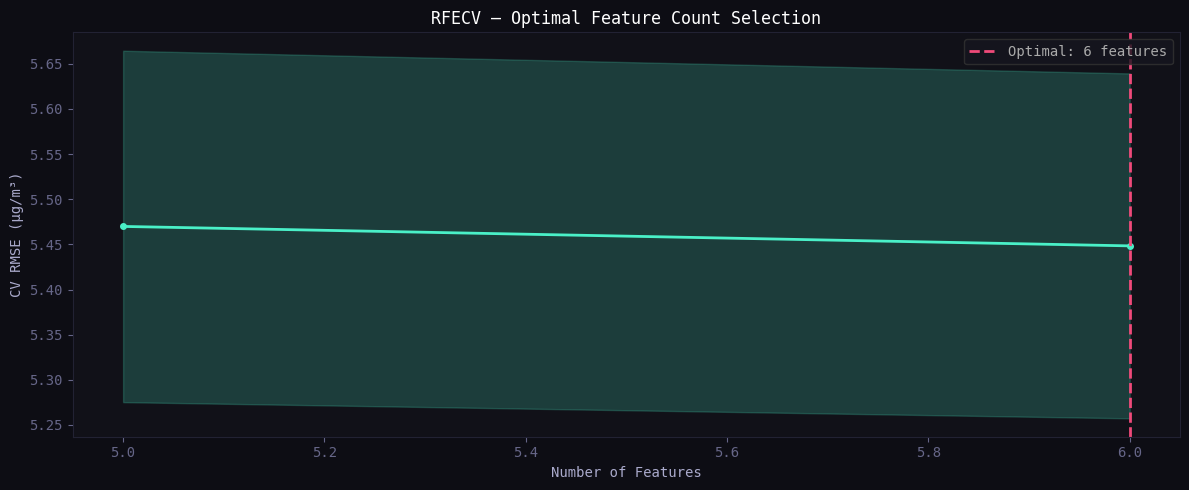

✓ Saved → outputs/04_rfecv_curve.png

RFECV selected features: ['Optical_Depth_055', 'month_cos', 'month_sin', 'wind_speed', 'month', 'day_of_week']


In [9]:
X_v4 = X_v2[FEATURES_V4].copy()

rf_base = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

tscv_rfe = TimeSeriesSplit(n_splits=5)
rfecv = RFECV(
    estimator=rf_base,
    step=1,
    cv=tscv_rfe,
    scoring='neg_root_mean_squared_error',
    min_features_to_select=5,
    n_jobs=-1,
    verbose=0
)

print('Running RFECV (this may take 1–2 minutes)...')
rfecv.fit(X_v4, y)

FEATURES_V5 = [f for f, s in zip(FEATURES_V4, rfecv.support_) if s]
print(f'\nOptimal # features  : {rfecv.n_features_}')
print(f'Selected features   : {len(FEATURES_V5)}')
print(f'Eliminated features : {len(FEATURES_V4) - len(FEATURES_V5)}')

# RFECV curve
fig, ax = plt.subplots(figsize=(12, 5))
cv_scores = -rfecv.cv_results_['mean_test_score']  # RMSE
cv_std    = rfecv.cv_results_['std_test_score']
n_feats   = range(rfecv.min_features_to_select,
                  rfecv.min_features_to_select + len(cv_scores))

ax.plot(n_feats, cv_scores, color='#4af0c8', linewidth=2, marker='o', markersize=4)
ax.fill_between(n_feats, cv_scores - cv_std, cv_scores + cv_std,
                alpha=0.2, color='#4af0c8')
ax.axvline(rfecv.n_features_, color='#f04a7a', linestyle='--',
           linewidth=2, label=f'Optimal: {rfecv.n_features_} features')
ax.set_xlabel('Number of Features')
ax.set_ylabel('CV RMSE (µg/m³)')
ax.set_title('RFECV — Optimal Feature Count Selection', color='#fff')
ax.legend(facecolor='#16161f', labelcolor='#aaa', edgecolor='#333')

plt.tight_layout()
plt.savefig('outputs/04_rfecv_curve.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d14')
plt.show()
print('✓ Saved → outputs/04_rfecv_curve.png')
print(f'\nRFECV selected features: {FEATURES_V5}')

## 9. Step 6 — Permutation Importance (Random Forest Baseline)

RF baseline — Train R² = 0.9552
RF baseline — Test  R² = 0.9485


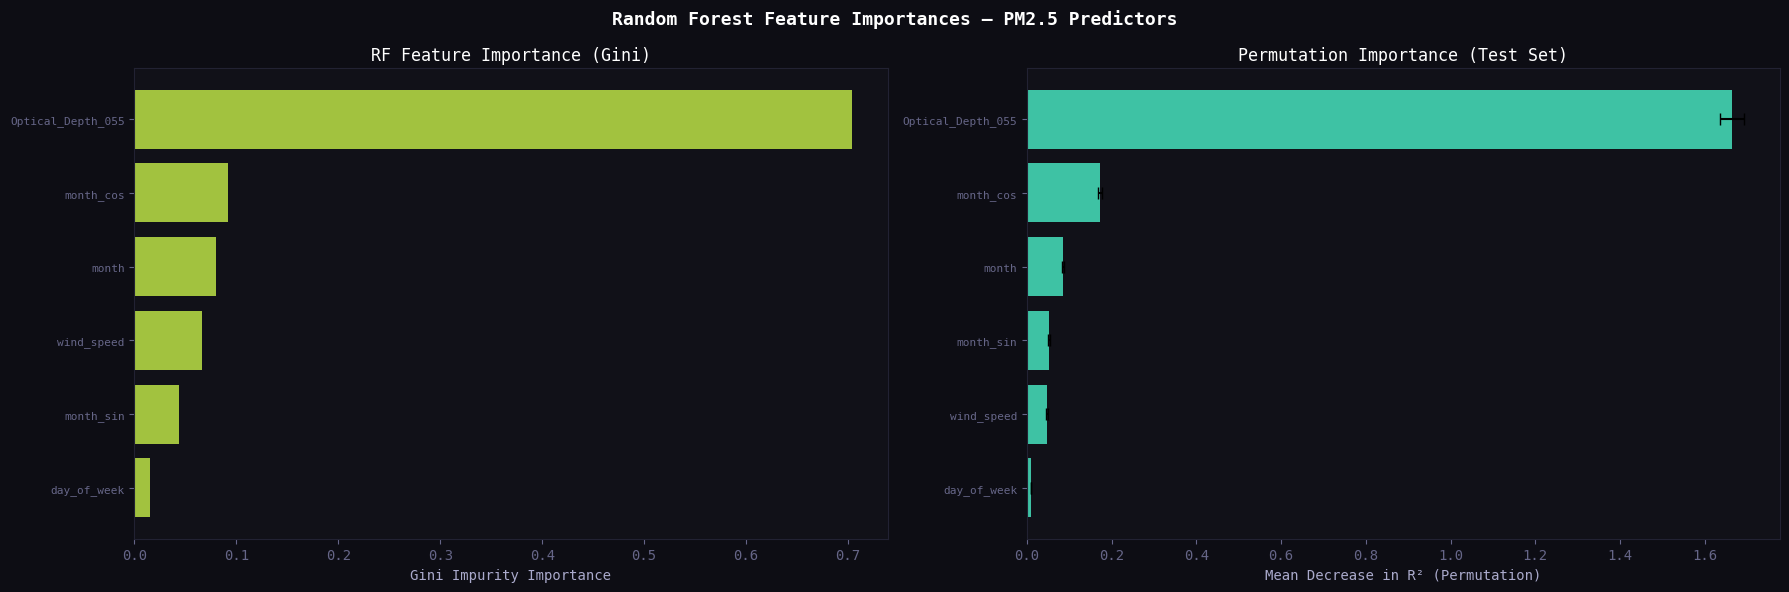

✓ Saved → outputs/04_rf_importance.png


In [10]:
# Train RF on RFECV-selected features to get permutation importance
X_final_pool = X_v2[FEATURES_V5]

# Temporal split — respect time ordering
split_idx = int(len(X_final_pool) * 0.80)
X_tr, X_te = X_final_pool.iloc[:split_idx], X_final_pool.iloc[split_idx:]
y_tr, y_te = y.iloc[:split_idx], y.iloc[split_idx:]

rf_perm = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=4,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
rf_perm.fit(X_tr, y_tr)

y_pred_tr = rf_perm.predict(X_tr)
y_pred_te = rf_perm.predict(X_te)
print(f'RF baseline — Train R² = {r2_score(y_tr, y_pred_tr):.4f}')
print(f'RF baseline — Test  R² = {r2_score(y_te, y_pred_te):.4f}')

# Impurity-based importances
imp_df = pd.DataFrame({
    'feature'    : FEATURES_V5,
    'importance' : rf_perm.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Permutation importances
perm = permutation_importance(
    rf_perm, X_te, y_te,
    n_repeats=15,
    random_state=42,
    n_jobs=-1
)
perm_df = pd.DataFrame({
    'feature'      : FEATURES_V5,
    'perm_mean'    : perm.importances_mean,
    'perm_std'     : perm.importances_std
}).sort_values('perm_mean', ascending=False).reset_index(drop=True)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(FEATURES_V5) * 0.4)))

ax = axes[0]
top_n = min(20, len(imp_df))
ax.barh(range(top_n), imp_df['importance'][:top_n],
        color=PALETTE[0], alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels(imp_df['feature'][:top_n], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Gini Impurity Importance')
ax.set_title('RF Feature Importance (Gini)', color='#fff')

ax = axes[1]
top_n2 = min(20, len(perm_df))
ax.barh(range(top_n2), perm_df['perm_mean'][:top_n2],
        xerr=perm_df['perm_std'][:top_n2],
        color=PALETTE[1], alpha=0.8, capsize=4)
ax.set_yticks(range(top_n2))
ax.set_yticklabels(perm_df['feature'][:top_n2], fontsize=8)
ax.invert_yaxis()
ax.axvline(0, color='white', linewidth=0.5)
ax.set_xlabel('Mean Decrease in R² (Permutation)')
ax.set_title('Permutation Importance (Test Set)', color='#fff')

plt.suptitle('Random Forest Feature Importances — PM2.5 Predictors',
             color='#fff', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/04_rf_importance.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d14')
plt.show()
print('✓ Saved → outputs/04_rf_importance.png')

## 10. Step 7 — Consensus Feature Ranking

CONSENSUS FEATURE RANKING (lower rank = better)
          feature  mi_rank  lasso_rank  gini_rank  perm_rank  rfecv_selected  consensus_rank
Optical_Depth_055      1.0         1.0        1.0        1.0               1             1.0
        month_cos      4.0         2.0        2.0        2.0               1             2.2
            month      2.0         5.0        3.0        3.0               1             2.8
       wind_speed      3.0         4.0        4.0        5.0               1             3.4
        month_sin      5.0         3.0        5.0        4.0               1             3.6
      day_of_week      6.0         6.0        6.0        6.0               1             5.0


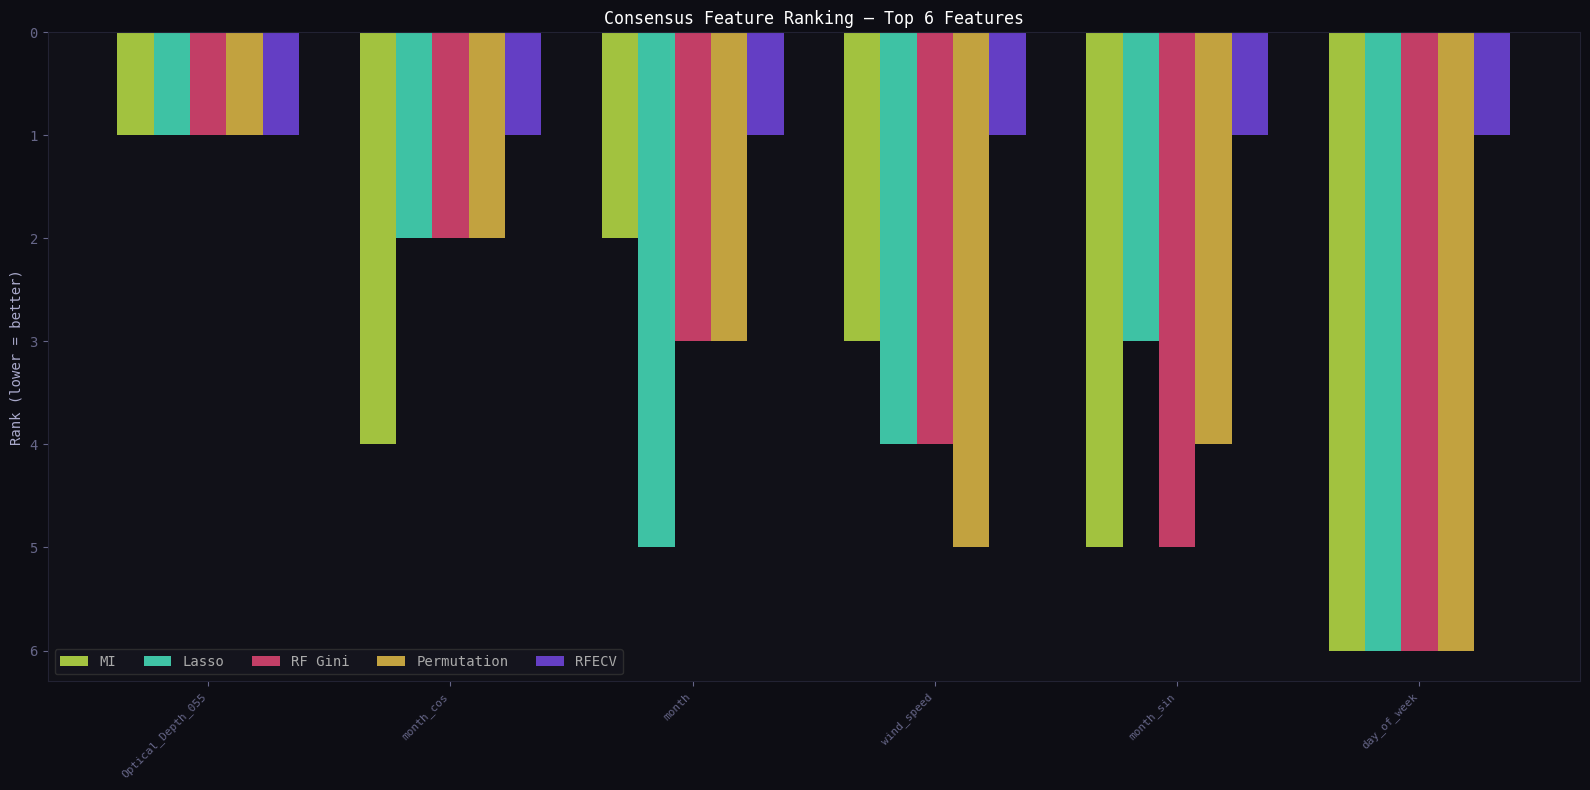

✓ Saved → outputs/04_consensus_ranking.png


In [11]:
# Build a consensus table: rank each feature across all selection methods
all_features = list(set(FEATURES_V3))  # Post-MI pool

def rank_series(series, ascending=False):
    """Return rank (1=best) for a series, filling missing with worst."""
    s = series.fillna(series.min() if ascending else 0)
    return s.rank(ascending=ascending, method='min')

consensus = pd.DataFrame({'feature': all_features}).set_index('feature')

# Method 1: Mutual Information
mi_map = mi_df.set_index('feature')['mi_score']
consensus['mi_score'] = mi_map.reindex(all_features).fillna(0)
consensus['mi_rank']  = rank_series(consensus['mi_score'], ascending=False)

# Method 2: Lasso |coef|
lasso_map = lasso_coef.set_index('feature')['abs_coef']
consensus['lasso_coef'] = lasso_map.reindex(all_features).fillna(0)
consensus['lasso_rank'] = rank_series(consensus['lasso_coef'], ascending=False)

# Method 3: RF Gini importance
gini_map = imp_df.set_index('feature')['importance']
consensus['gini_imp']  = gini_map.reindex(all_features).fillna(0)
consensus['gini_rank'] = rank_series(consensus['gini_imp'], ascending=False)

# Method 4: Permutation importance
perm_map = perm_df.set_index('feature')['perm_mean']
consensus['perm_imp']  = perm_map.reindex(all_features).fillna(0)
consensus['perm_rank'] = rank_series(consensus['perm_imp'], ascending=False)

# Method 5: RFECV selected?
consensus['rfecv_selected'] = [1 if f in FEATURES_V5 else 0 for f in all_features]
consensus['rfecv_rank']     = [1 if f in FEATURES_V5 else len(all_features) for f in all_features]

# Consensus score = mean rank (lower = better)
rank_cols = ['mi_rank','lasso_rank','gini_rank','perm_rank','rfecv_rank']
consensus['consensus_rank'] = consensus[rank_cols].mean(axis=1)
consensus = consensus.sort_values('consensus_rank').reset_index()

print('='*60)
print('CONSENSUS FEATURE RANKING (lower rank = better)')
print('='*60)
display_cols = ['feature','mi_rank','lasso_rank','gini_rank','perm_rank','rfecv_selected','consensus_rank']
print(consensus[display_cols].head(25).to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(16, 8))
top_n = min(25, len(consensus))
top_c = consensus.head(top_n)

rank_cols_plot = ['mi_rank','lasso_rank','gini_rank','perm_rank','rfecv_rank']
labels_plot    = ['MI','Lasso','RF Gini','Permutation','RFECV']
x = np.arange(top_n)
width = 0.15

for i, (col, lbl) in enumerate(zip(rank_cols_plot, labels_plot)):
    ax.bar(x + i * width, top_c[col], width, label=lbl,
           color=PALETTE[i % len(PALETTE)], alpha=0.8)

ax.set_xticks(x + 2 * width)
ax.set_xticklabels(top_c['feature'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Rank (lower = better)')
ax.set_title(f'Consensus Feature Ranking — Top {top_n} Features', color='#fff')
ax.legend(facecolor='#16161f', labelcolor='#aaa', edgecolor='#333', ncol=5)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/04_consensus_ranking.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d14')
plt.show()
print('✓ Saved → outputs/04_consensus_ranking.png')

## 11. Final Feature Set Selection

In [12]:
# Select top-N features by consensus rank that also exist in the data
# Strategy: take top features until we have a stable, non-redundant set
TOP_N_FEATURES = min(20, len(consensus))  # cap at 20 features for generalizability

FINAL_FEATURES = consensus.head(TOP_N_FEATURES)['feature'].tolist()

# Ensure all final features actually exist in df
FINAL_FEATURES = [f for f in FINAL_FEATURES if f in df.columns]

print('='*60)
print(f'FINAL SELECTED FEATURES ({len(FINAL_FEATURES)} features)')
print('='*60)
for i, f in enumerate(FINAL_FEATURES):
    rank = consensus[consensus['feature'] == f]['consensus_rank'].values[0]
    print(f'  {i+1:>2}. {f:<35} (consensus rank: {rank:.2f})')

# Categorize features
cat_sat  = [f for f in FINAL_FEATURES if any(k in f for k in ['aer_ai','no2','so2','co','Optical','viirs','ndvi','ndbi'])]
cat_met  = [f for f in FINAL_FEATURES if any(k in f for k in ['temp','wind','rh','precip','pressure','stagnation'])]
cat_time = [f for f in FINAL_FEATURES if any(k in f for k in ['month','day','week','season','sin','cos','ramadan','weekend'])]
cat_lag  = [f for f in FINAL_FEATURES if 'lag' in f or 'roll' in f]
cat_stn  = [f for f in FINAL_FEATURES if f.startswith('stn_')]

print(f'\nFeature category breakdown:')
print(f'  Satellite/remote sensing : {len(cat_sat):>2} — {cat_sat}')
print(f'  Meteorological           : {len(cat_met):>2} — {cat_met}')
print(f'  Temporal/calendar        : {len(cat_time):>2} — {cat_time}')
print(f'  Lag/rolling statistics   : {len(cat_lag):>2} — {cat_lag}')
print(f'  Station encoding         : {len(cat_stn):>2} — {cat_stn}')

FINAL SELECTED FEATURES (6 features)
   1. Optical_Depth_055                   (consensus rank: 1.00)
   2. month_cos                           (consensus rank: 2.20)
   3. month                               (consensus rank: 2.80)
   4. wind_speed                          (consensus rank: 3.40)
   5. month_sin                           (consensus rank: 3.60)
   6. day_of_week                         (consensus rank: 5.00)

Feature category breakdown:
  Satellite/remote sensing :  2 — ['Optical_Depth_055', 'month_cos']
  Meteorological           :  1 — ['wind_speed']
  Temporal/calendar        :  4 — ['month_cos', 'month', 'month_sin', 'day_of_week']
  Lag/rolling statistics   :  0 — []
  Station encoding         :  0 — []


## 12. Export Modeling Dataset

In [13]:
# Build final modeling DataFrame
meta_cols = ['date', 'station']
export_cols = meta_cols + FINAL_FEATURES + [TARGET]
export_cols = [c for c in export_cols if c in df.columns]

df_export = df[export_cols].dropna(subset=FINAL_FEATURES + [TARGET])
df_export = df_export.sort_values(['station', 'date']).reset_index(drop=True)

# Save
OUT_PATH = 'data/processed/modeling_dataset.csv'
df_export.to_csv(OUT_PATH, index=False)

print('='*60)
print('EXPORT COMPLETE')
print('='*60)
print(f'  Output file  : {OUT_PATH}')
print(f'  Shape        : {df_export.shape[0]:,} rows × {df_export.shape[1]} columns')
print(f'  Features     : {len(FINAL_FEATURES)}')
print(f'  Target       : {TARGET} (µg/m³)')
print(f'  PM2.5 range  : {df_export[TARGET].min():.1f}–{df_export[TARGET].max():.1f} µg/m³')
print(f'  Date range   : {df_export["date"].min()} → {df_export["date"].max()}')
print(f'  Stations     : {df_export["station"].nunique()}')

# Save feature list for downstream notebooks
import json
feature_config = {
    'final_features': FINAL_FEATURES,
    'target': TARGET,
    'n_features': len(FINAL_FEATURES),
    'category_satellite': cat_sat,
    'category_meteorology': cat_met,
    'category_temporal': cat_time,
    'category_lag_rolling': cat_lag,
    'category_station': cat_stn,
    'vif_threshold': VIF_THRESHOLD,
    'lasso_alpha': float(lasso_cv.alpha_),
    'rfecv_n_optimal': int(rfecv.n_features_),
}
with open('data/processed/feature_config.json', 'w') as fp:
    json.dump(feature_config, fp, indent=2)
print('  Config saved : data/processed/feature_config.json')

# Final peek
print('\nHead of modeling dataset:')
print(df_export.head(3).to_string())

EXPORT COMPLETE
  Output file  : data/processed/modeling_dataset.csv
  Shape        : 12,928 rows × 9 columns
  Features     : 6
  Target       : pm25 (µg/m³)
  PM2.5 range  : 45.8–200.0 µg/m³
  Date range   : 2019-01-01 00:00:00 → 2023-12-31 00:00:00
  Stations     : 8
  Config saved : data/processed/feature_config.json

Head of modeling dataset:
        date         station  Optical_Depth_055  month_cos  month  wind_speed  month_sin  day_of_week        pm25
0 2019-01-01  Federal_B_Area           0.379310   0.866025      1    2.264397        0.5            1  118.228647
1 2019-01-02  Federal_B_Area           0.215778   0.866025      1    2.226081        0.5            2  109.819853
2 2019-01-03  Federal_B_Area           0.403915   0.866025      1    1.365181        0.5            3  125.848902


## 13. Feature Pipeline Summary Figure

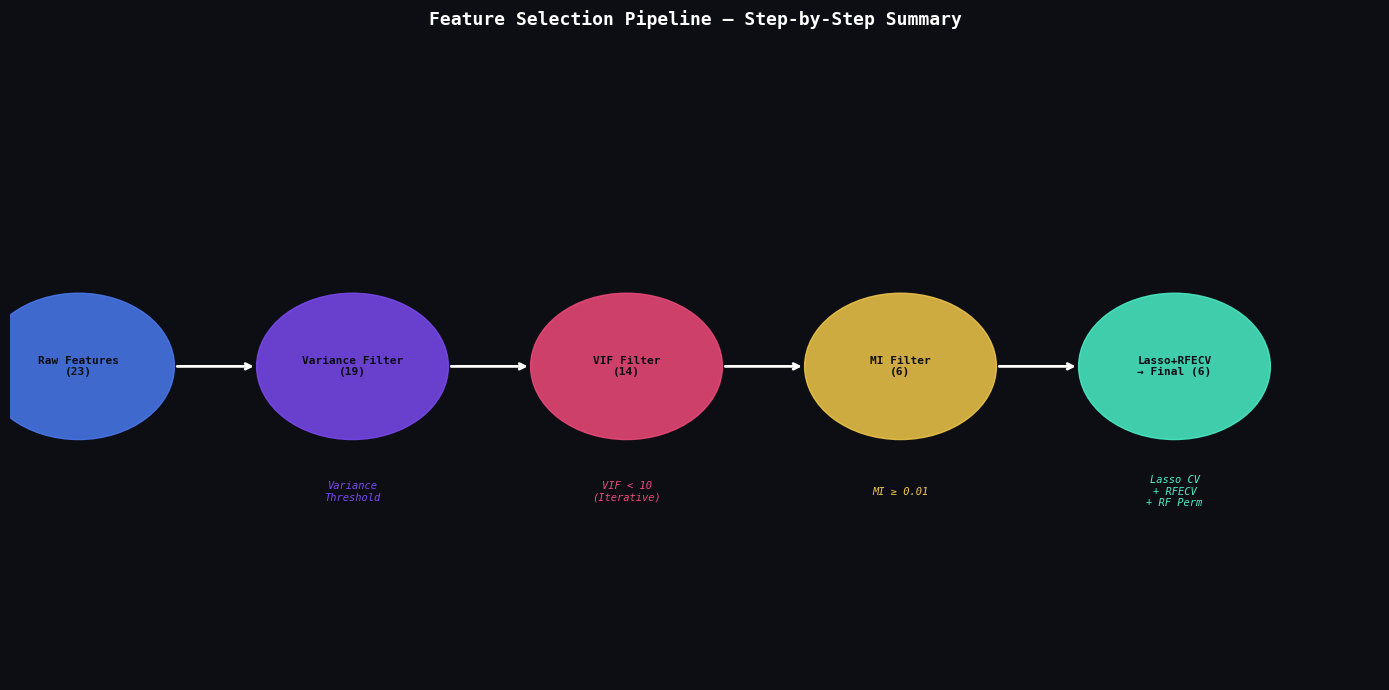

✓ Saved → outputs/04_feature_pipeline.png


In [14]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

# Pipeline stages
stages = [
    (0.5, 3.0, f'Raw Features\n({len(FEATURES)})', '#4a7af0'),
    (2.5, 3.0, f'Variance Filter\n({len(FEATURES_V1)})', '#7a4af0'),
    (4.5, 3.0, f'VIF Filter\n({len(FEATURES_V2)})', '#f04a7a'),
    (6.5, 3.0, f'MI Filter\n({len(FEATURES_V3)})', '#f0c84a'),
    (8.5, 3.0, f'Lasso+RFECV\n→ Final ({len(FINAL_FEATURES)})', '#4af0c8'),
]

for (x, y, label, color) in stages:
    circle = plt.Circle((x, y), 0.7, color=color, alpha=0.85, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=8, color='#0d0d14', fontweight='bold', zorder=4)

# Arrows
for i in range(len(stages) - 1):
    x1, y1 = stages[i][0] + 0.7, stages[i][1]
    x2, y2 = stages[i+1][0] - 0.7, stages[i+1][1]
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='white', lw=2))

# Labels below
methods = ['', 'Variance\nThreshold', 'VIF < 10\n(Iterative)', 'MI ≥ 0.01', 'Lasso CV\n+ RFECV\n+ RF Perm']
for i, (x, y, _, color) in enumerate(stages):
    ax.text(x, y - 1.2, methods[i], ha='center', va='center',
            fontsize=7.5, color=color, style='italic')

ax.set_title('Feature Selection Pipeline — Step-by-Step Summary',
             color='#fff', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('outputs/04_feature_pipeline.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d14')
plt.show()
print('✓ Saved → outputs/04_feature_pipeline.png')

## 14. Summary

In [15]:
print('=' * 60)
print('✅ NOTEBOOK 04 COMPLETE — FEATURE SELECTION')
print('=' * 60)
print()
print('Pipeline summary:')
print(f'  Step 0 — Raw features          : {len(FEATURES)}')
print(f'  Step 1 — After variance filter  : {len(FEATURES_V1)}')
print(f'  Step 2 — After VIF removal      : {len(FEATURES_V2)}')
print(f'  Step 3 — After MI filter        : {len(FEATURES_V3)}')
print(f'  Step 4 — After Lasso            : {len(FEATURES_V4)}')
print(f'  Step 5 — After RFECV            : {len(FEATURES_V5)}')
print(f'  Step 6 — Final (consensus top-N): {len(FINAL_FEATURES)}')
print()
print('Saved outputs:')
for f in [
    'outputs/04_vif_analysis.png',
    'outputs/04_mutual_information.png',
    'outputs/04_lasso_selection.png',
    'outputs/04_rfecv_curve.png',
    'outputs/04_rf_importance.png',
    'outputs/04_consensus_ranking.png',
    'outputs/04_feature_pipeline.png',
    'data/processed/modeling_dataset.csv',
    'data/processed/feature_config.json',
]:
    exists = '✓' if Path(f).exists() else '?'
    print(f'  {exists} {f}')
print()
print('NEXT: Run 05_models.ipynb')
print('  → Load data/processed/modeling_dataset.csv')
print('  → Train Random Forest, XGBoost, LightGBM, SVR, Prophet')

✅ NOTEBOOK 04 COMPLETE — FEATURE SELECTION

Pipeline summary:
  Step 0 — Raw features          : 23
  Step 1 — After variance filter  : 19
  Step 2 — After VIF removal      : 14
  Step 3 — After MI filter        : 6
  Step 4 — After Lasso            : 6
  Step 5 — After RFECV            : 6
  Step 6 — Final (consensus top-N): 6

Saved outputs:
  ✓ outputs/04_vif_analysis.png
  ✓ outputs/04_mutual_information.png
  ✓ outputs/04_lasso_selection.png
  ✓ outputs/04_rfecv_curve.png
  ✓ outputs/04_rf_importance.png
  ✓ outputs/04_consensus_ranking.png
  ✓ outputs/04_feature_pipeline.png
  ✓ data/processed/modeling_dataset.csv
  ✓ data/processed/feature_config.json

NEXT: Run 05_models.ipynb
  → Load data/processed/modeling_dataset.csv
  → Train Random Forest, XGBoost, LightGBM, SVR, Prophet
